# Samit Bhisikar
## A_A3_33
## Practical 1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()
print(df.shape)

(891, 12)


In [6]:
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.describe()
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df["Age"].fillna(df["Age"].median(),inplace=True)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [9]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [10]:
df.drop("Cabin",axis=1,inplace=True)

In [11]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

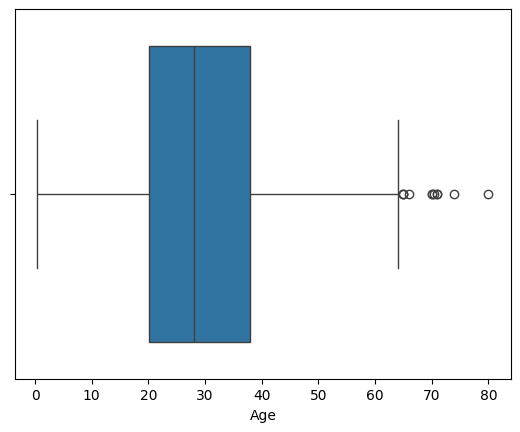

In [12]:
sns.boxplot(x=df["Age"])
plt.show()

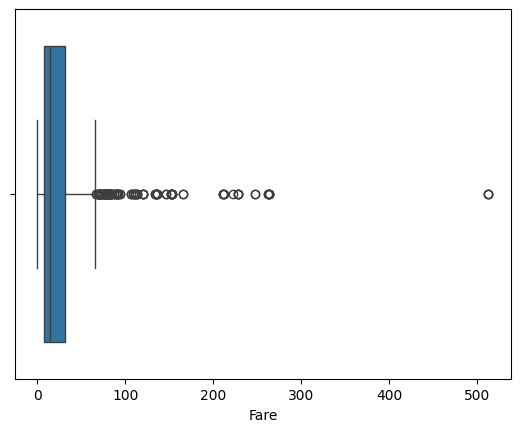

In [13]:
sns.boxplot(x=df["Fare"])
plt.show()

In [14]:
Q1=df["Fare"].quantile(0.25)
Q3=df["Fare"].quantile(0.75)
IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df=df[(df["Fare"]>=lower)&(df["Fare"] <=upper)]

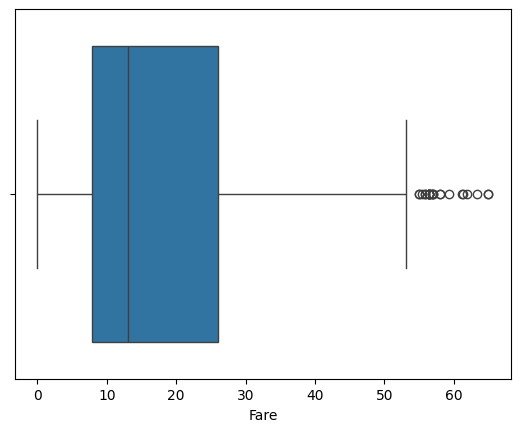

In [15]:
sns.boxplot(x=df["Fare"])
plt.show()

In [16]:
df["Sex"]=df["Sex"].replace("male",0)
df["Sex"]=df["Sex"].replace("female",1)

In [17]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",0,NaN,0,0,330877,8.4583,Q


In [18]:
df["Embarked"]=df["Embarked"].replace("S",0)
df["Embarked"]=df["Embarked"].replace("C",1)
df["Embarked"]=df["Embarked"].replace("Q",2)

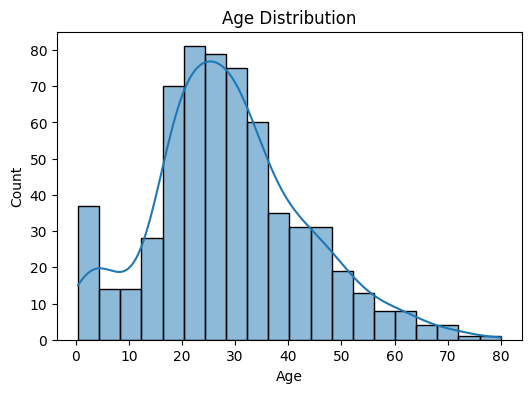

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"],bins=20,kde=True)
plt.title("Age Distribution")
plt.show()

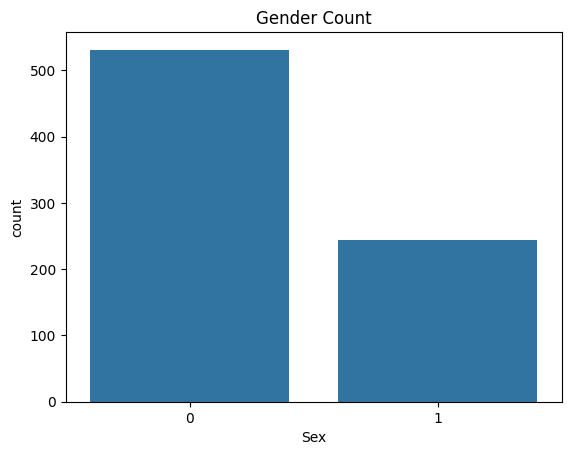

In [20]:
sns.countplot(x="Sex",data=df)
plt.title("Gender Count")
plt.show()

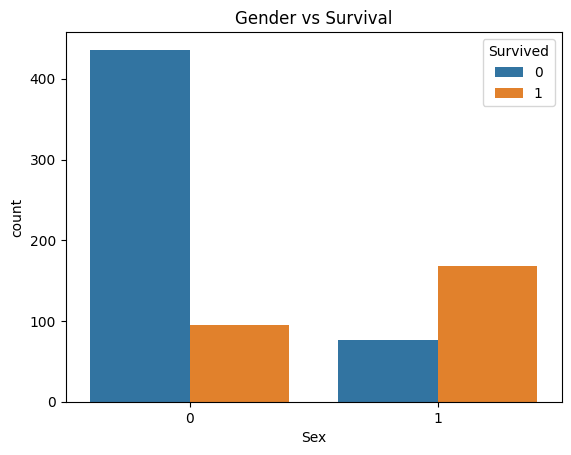

In [21]:
sns.countplot(x="Sex",hue="Survived",data=df)
plt.title("Gender vs Survival")
plt.show()

Text(0.5, 1.0, 'Age vs Fare')

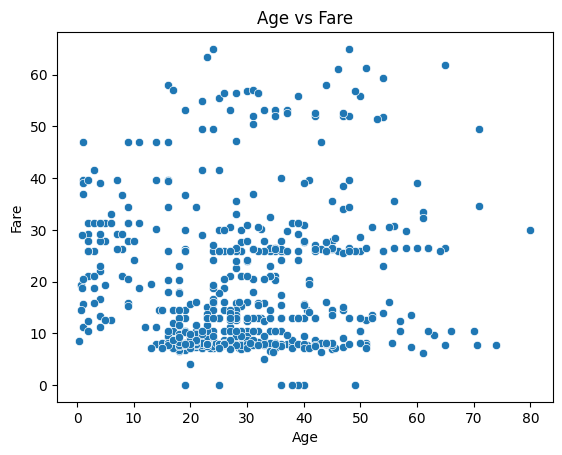

In [22]:
sns.scatterplot(x="Age",y="Fare",data=df)
plt.title("Age vs Fare")

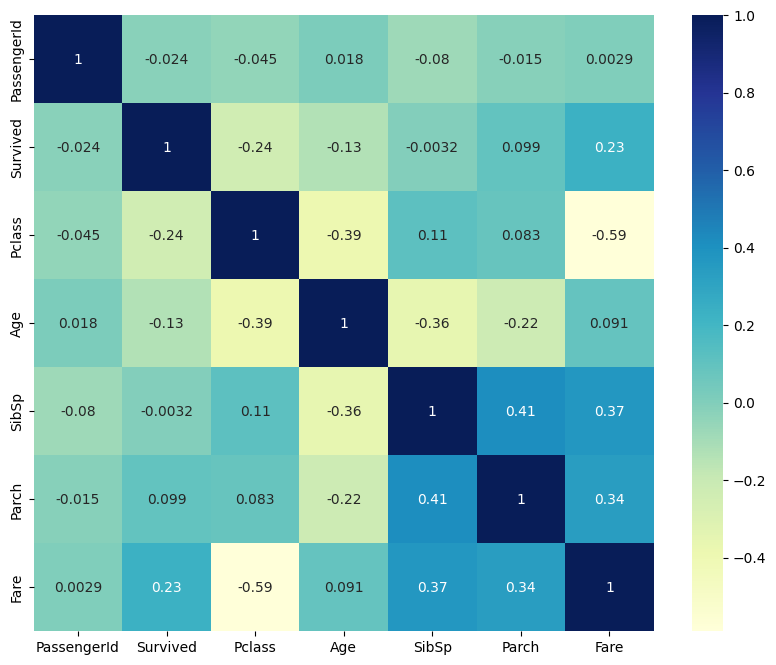

In [23]:
plt.figure(figsize=(10,8))
numeric_df=df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),
annot=True,
cmap='YlGnBu')
plt.show()

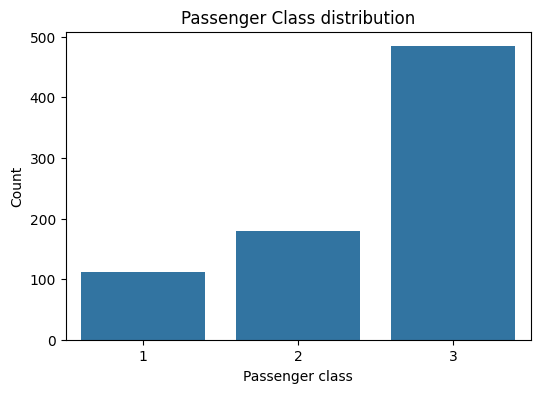

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass",data=df)

plt.title("Passenger Class distribution")
plt.xlabel("Passenger class")
plt.ylabel("Count")
plt.show()

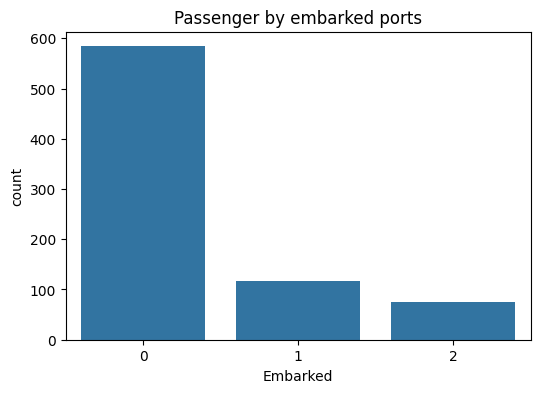

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="Embarked",data=df)
plt.title("Passenger by embarked ports")
plt.show()

In [26]:
#Feature scaling
x=df.drop("Survived",axis=1)
y=df["Survived"]
X=x.drop(["PassengerId","Name","Ticket"],axis=1)

In [27]:
#Standard scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X[["Age","Fare"]]=scaler.fit_transform(X[["Age","Fare"]])
X.head(15)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,-0.483866,1,0,-0.779117,0
2,3,1,-0.205244,0,0,-0.729373,0
3,1,1,0.421653,1,0,2.599828,0
4,3,0,0.421653,0,0,-0.720161,0
5,3,0,NaN,0,0,-0.690071,2
6,1,0,1.745103,0,0,2.508630,0
7,3,0,-1.876971,3,1,0.239725,0
8,3,1,-0.135589,0,2,-0.492935,0
9,2,1,-1.041108,1,0,0.902677,1
10,3,1,-1.737660,1,1,-0.082693,0


In [28]:
#Train test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=4)

print("training data:",X_train.shape)
print("testing data:",X_train.shape)

training data: (620, 7)
testing data: (620, 7)


In [29]:
print(X_train.head())

     Pclass Sex       Age  SibSp  Parch      Fare Embarked
497       3   0       NaN      0      0 -0.200606        0
349       3   0  0.909240      0      0 -0.675022        0
671       1   0  0.143032      1      0  2.518763        0
500       3   0 -0.832142      0      0 -0.675022        0
248       1   0  0.560964      1      1  2.559605        0


In [30]:
print("testing data:",X_train.shape)

testing data: (620, 7)
